In [1]:
# If not running the full notebook linearly, run this block to import all dependencies and functions
import pandas as pd
import numpy as np

from dpp.grid_helpers import reindex_rect_grid, assign_grid
from plotting.python_plots import plot_sample, plot_points
from dpp.inference_dpp import iterative_refinement as iterative_refinement_dpp
from gpp.inference_strauss import iterative_refinement as iterative_refinement_strauss
from gpp.inference_gpp_backend import df_to_configs

# Inference Demonstration

This notebook accompanies our pre-print [[1]](#ref1). 

In this notebook, we showcase the estimation algorithm to obtain models from three spatial point process models, a discrete determinantal point process (DPP) model and two continuous Gibbs point process (GPP) models. The DPP uses a Gaussian interaction kernel, while the GPP models use a Strauss interaction function and a modified Diggle-Gates-Stibbard interaction function, respectively.

We begin by importing the data (see the notebook `demo_data.ipynb` for more detail) and extracting the snapshots of standing pedestrians.

### References
<a id="ref1"></a>[1] L. Sickert Karam, R. M. Castro, M. Schoukens, and A. Corbetta, "Modeling inhomogeneous spatial point configurations with applications to replicated patterns in waiting crowds," arXiv preprint [arXiv:2606.14532](https://arxiv.org/abs/2606.14532) [physics.soc-ph], 2026.

In [2]:
import pandas as pd

data_wwalking = pd.read_parquet("data/snapshots_wwalking.parquet")
data = data_wwalking.query("stand_or_walk == 0").copy()
data.drop(columns=['x_vel_SG', 'y_vel_SG', 'stand_or_walk'], inplace=True)

print(data.columns)

Index(['time_ms', 'object_identifier', 'x_position_mm', 'y_position_mm',
       'frac_standing', 'occupancy'],
      dtype='object')


## DPP Inference

For DPPs, it's useful to have our snapshots as just arrays of 2D coordinates instead of `pandas` DataFrames. So, let's generate a `numpy` array of `dtype=object` that contains all snapshots. This is shown for clarity, but was already done beforehand, and can be found at `data/samples.npy`. For validation later on, it is also useful to save it as a `.csv` file.

In [4]:
import numpy as np

# get snapshots from the DataFrame, as in the data demo
snapshots = [data.groupby("time_ms").get_group(t) for t in data["time_ms"].unique()]

# generate an array of arrays, one for each snapshot
samples = np.empty(len(snapshots), dtype=object)
for i, s in enumerate(snapshots):
    samples[i] = s[["x_position_mm", "y_position_mm"]].to_numpy()

# np.save("data/samples.npy", samples) # pre-saved, uncomment to overwrite

df = pd.concat(
    [pd.DataFrame({"pattern_id": i + 1, "x": p[:, 0], "y": p[:, 1]})
     for i, p in enumerate(samples)],
    ignore_index=True,
)
# df.to_csv("data/samples.csv", index=False) # pre-saved, uncomment to overwrite

As described in our pre-print, we restrict ourselves to a subregion of the entire platform for inference. In addition, for DPPs we need to discretize our data. We choose a grid spaced by $500$ mm (i.e. $0.5$ m), as this approximately corresponds to the shoulder breadth of a pedestrian, and keeps the computational cost reasonable ($4160$ positions). For this demonstration, we shall only consider $10$ snapshots. To run the full estimation, simply run `inference_dpp.py` in the `dpp` folder of this repository. Be aware that it may take some time to run.

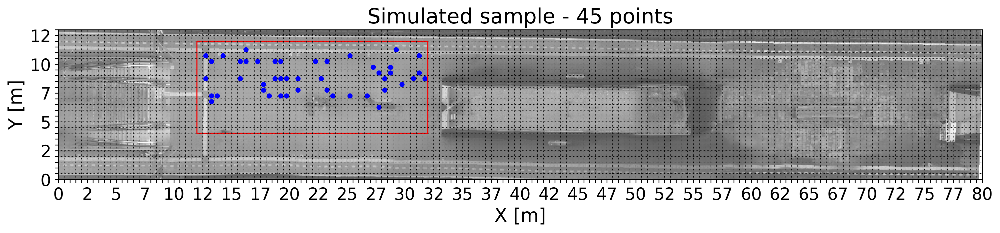

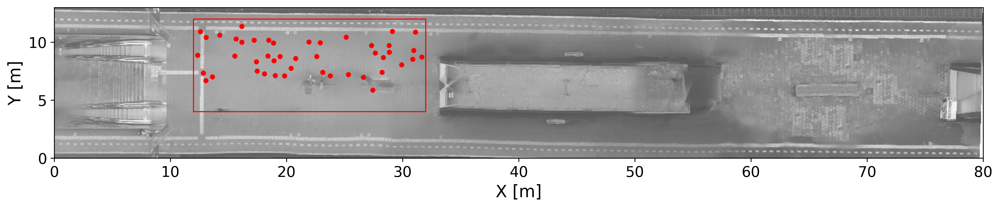

In [5]:
from dpp.grid_helpers import reindex_rect_grid, assign_grid
from plotting.python_plots import plot_sample, plot_points

# import grid and define rectangle for estimation
full_grid = pd.read_parquet("data/grid_500mm.parquet")
grid_rect = (24, 64, 8, 24)
grid_xmin, grid_xmax, grid_ymin, grid_ymax = grid_rect
rectangle_grid = full_grid[
    (full_grid['x_rounded'] >= grid_xmin) & (full_grid['x_rounded'] <= grid_xmax) &
    (full_grid['y_rounded'] >= grid_ymin) & (full_grid['y_rounded'] <= grid_ymax)
    ]
rectangle_grid = reindex_rect_grid(rectangle_grid)

# import data
data = pd.read_parquet("data/snapshots.parquet")

# restrict data to rectangle for estimation
rect = (12000, 32000, 4000+4136, 12000+4136)
xmin, xmax, ymin, ymax = rect
rectangle_data = data[
    (data['x_position_mm'] >= xmin) &
    (data['x_position_mm'] < xmax) &
    (data['y_position_mm'] + 4136 >= ymin) &
    (data['y_position_mm'] + 4136 < ymax)
]

# assign points to grid cells
assigned = assign_grid(rectangle_data, rectangle_grid)
times = rectangle_data["time_ms"].unique()
samples_rect = []
for t in times:
    idx = assigned.loc[assigned["time_ms"] == t, "grid_index"].to_numpy(dtype=np.int32)
    idx = np.unique(idx)  # remove duplicates within snapshot (multiple points in same cell)
    samples_rect.append(idx)
samples_rect = np.array(samples_rect, dtype=object)

# restrict to just a few samples for this demo
samples_rect = samples_rect[:10]

# plot the rectangle and samples on the platform
plot_grid = rectangle_grid.assign(
    x_rounded=rectangle_grid["x_rounded"] + grid_xmin,
    y_rounded=rectangle_grid["y_rounded"] + grid_ymin,
)

# plot sample and rectangle
for sample in samples_rect[:1]:
    plot_sample(plot_grid, sample, rectangle=grid_rect)

# plot original snapshot for comparison
snapshots_list = [rectangle_data.groupby("time_ms").get_group(t) for t in rectangle_data["time_ms"].unique()]
for snapshot in snapshots_list[:1]:
    plot_points(snapshot, rectangle=rect)


========== Iteration 1/2 ==========

========== Fold 1/2 ==========
Estimating pilot bandwidth...


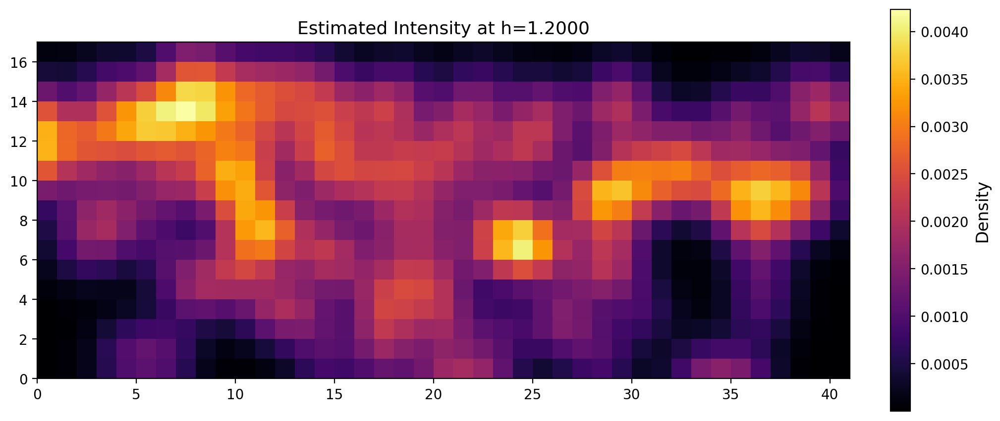

Estimating sigma via conditional likelihood on rectangle...
Local maxima (sigma, log-likelihood):
  Sigma: 0.1000, Log-Likelihood: -515.7575
  Sigma: 1.4000, Log-Likelihood: -510.1024


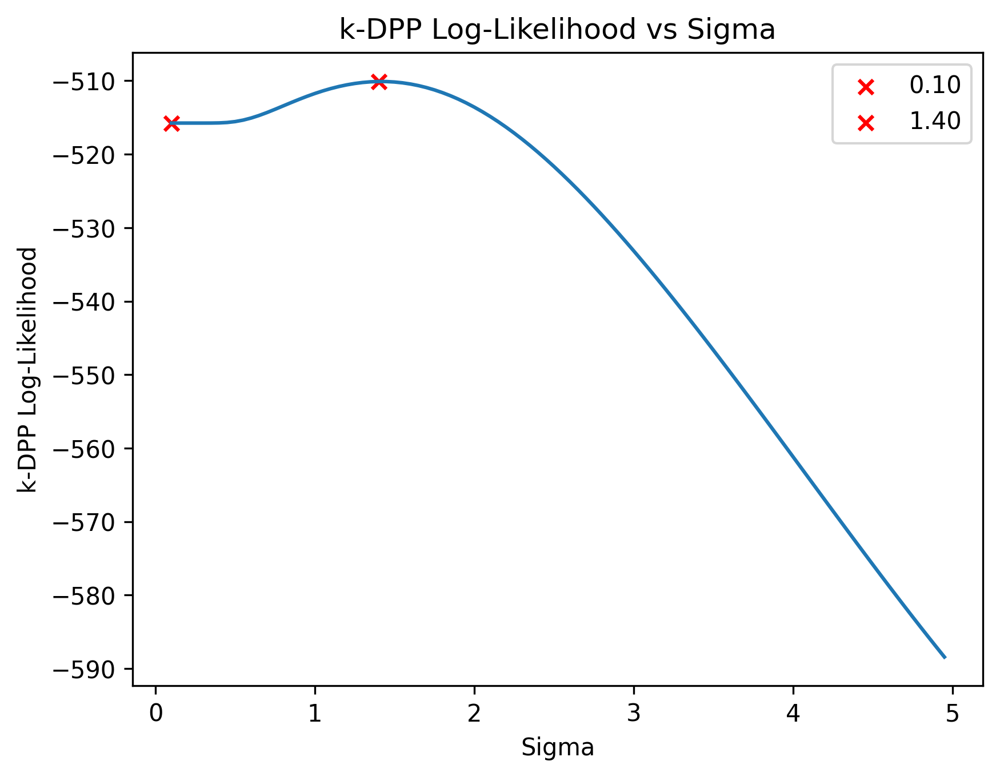

Evaluating candidate bandwidths...

--- Fold Results ---
Pilot bandwidth h     = 1.2000
Sigma                 = 1.4000
Candidate bandwidths h: 1.0800, 1.2000, 1.3200, 1.4400, 1.5600, 1.6800, 1.8000, 1.9200, 2.0400, 2.1600, 2.2800, 2.4000, 2.5200, 2.6400, 2.7600, 2.8800, 3.0000, 3.1200, 3.2400, 3.3600, 3.4800, 3.6000, 3.7200, 3.8400, 3.9600, 4.0800, 4.2000, 4.3200, 4.4400, 4.5600, 4.6800, 4.8000, 4.9200, 5.0400, 5.1600, 5.2800, 5.4000, 5.5200, 5.6400, 5.7600, 5.8800, 6.0000, 6.1200, 6.2400, 6.3600, 6.4800, 6.6000, 6.7200, 6.8400, 6.9600, 7.0800, 7.2000, 7.3200, 7.4400, 7.5600, 7.6800, 7.8000, 7.9200, 8.0400, 8.1600, 8.2800, 8.4000, 8.5200, 8.6400, 8.7600, 8.8800, 9.0000, 9.1200, 9.2400, 9.3600, 9.4800, 9.6000, 9.7200, 9.8400, 9.9600, 10.0800, 10.2000, 10.3200, 10.4400, 10.5600, 10.6800, 10.8000, 10.9200, 11.0400, 11.1600, 11.2800, 11.4000, 11.5200, 11.6400, 11.7600, 11.8800, 12.0000
Log-likelihoods on test set: -569.2759, -568.8420, -569.3943, -570.4271, -571.6621, -572.9493, -574.2141,

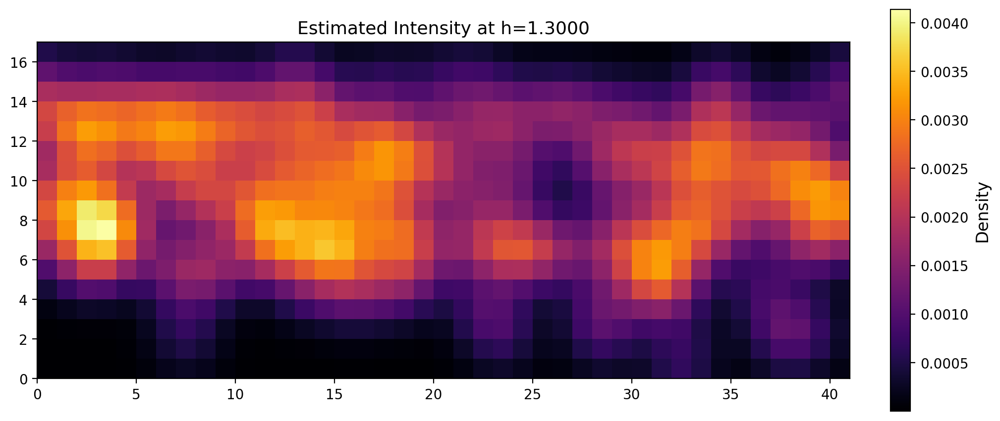

Estimating sigma via conditional likelihood on rectangle...
Local maxima (sigma, log-likelihood):
  Sigma: 0.1000, Log-Likelihood: -517.4346
  Sigma: 0.9500, Log-Likelihood: -516.2672


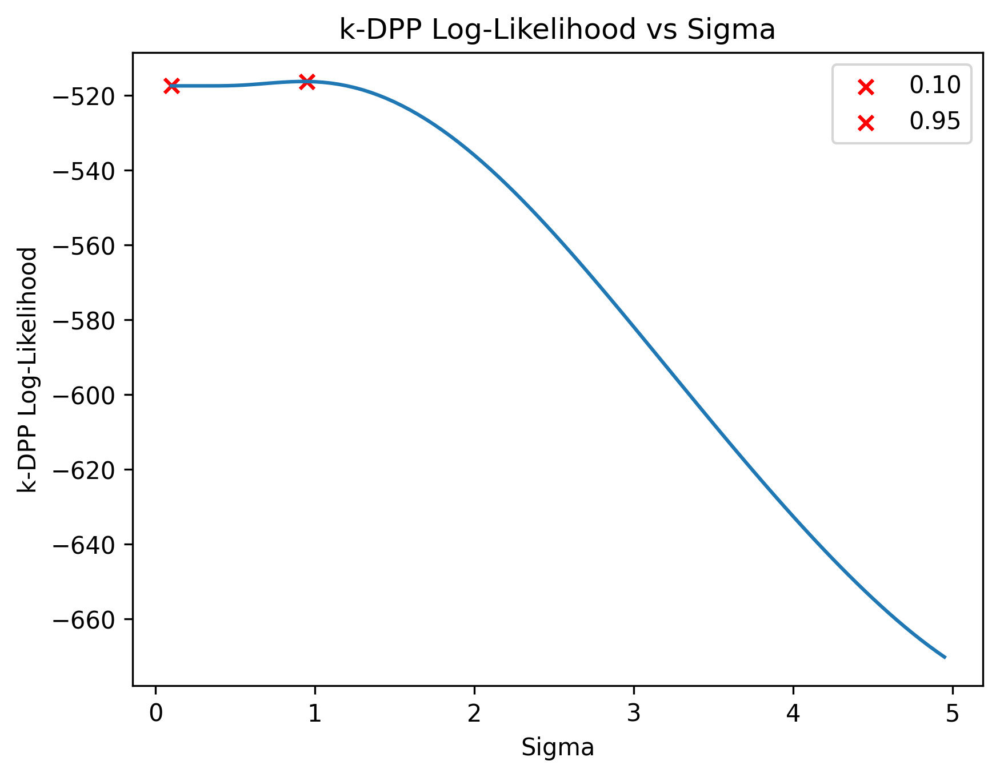

Evaluating candidate bandwidths...

--- Fold Results ---
Pilot bandwidth h     = 1.3000
Sigma                 = 0.9500
Candidate bandwidths h: 1.1700, 1.3000, 1.4300, 1.5600, 1.6900, 1.8200, 1.9500, 2.0800, 2.2100, 2.3400, 2.4700, 2.6000, 2.7300, 2.8600, 2.9900, 3.1200, 3.2500, 3.3800, 3.5100, 3.6400, 3.7700, 3.9000, 4.0300, 4.1600, 4.2900, 4.4200, 4.5500, 4.6800, 4.8100, 4.9400, 5.0700, 5.2000, 5.3300, 5.4600, 5.5900, 5.7200, 5.8500, 5.9800, 6.1100, 6.2400, 6.3700, 6.5000, 6.6300, 6.7600, 6.8900, 7.0200, 7.1500, 7.2800, 7.4100, 7.5400, 7.6700, 7.8000, 7.9300, 8.0600, 8.1900, 8.3200, 8.4500, 8.5800, 8.7100, 8.8400, 8.9700, 9.1000, 9.2300, 9.3600, 9.4900, 9.6200, 9.7500, 9.8800, 10.0100, 10.1400, 10.2700, 10.4000, 10.5300, 10.6600, 10.7900, 10.9200, 11.0500, 11.1800, 11.3100, 11.4400, 11.5700, 11.7000, 11.8300, 11.9600, 12.0900, 12.2200, 12.3500, 12.4800, 12.6100, 12.7400, 12.8700, 13.0000
Log-likelihoods on test set: -569.5209, -567.1755, -565.9795, -565.4271, -565.2282, -565.2222, -56

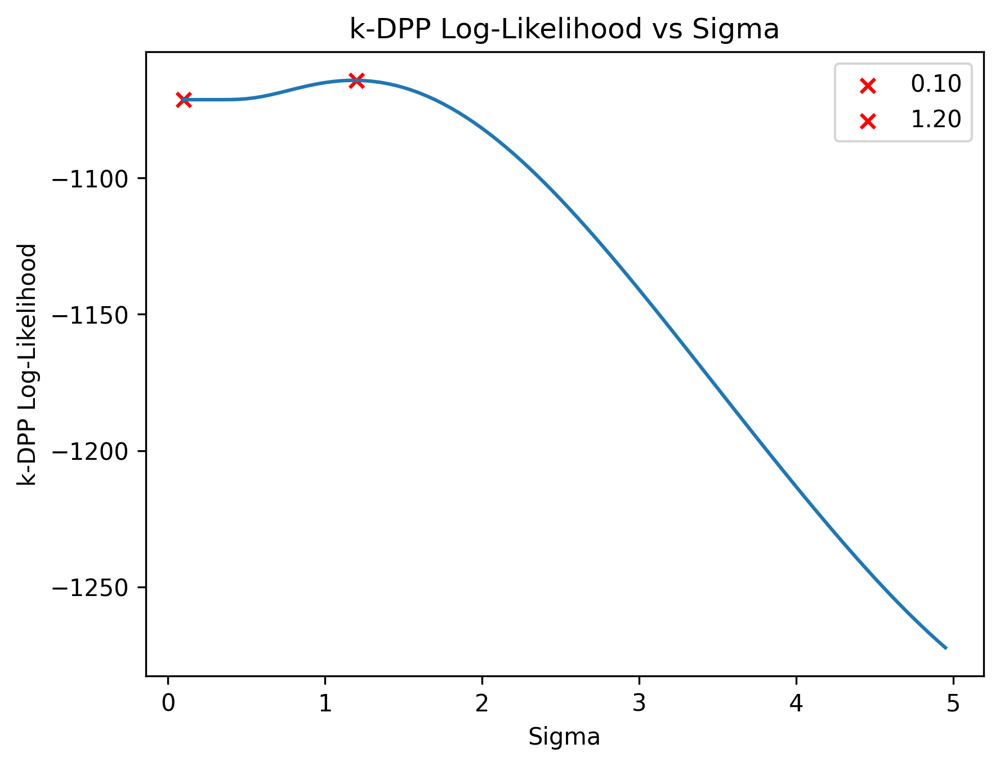

Selected bandwidth h: 0.5500
Selected sigma: 1.2000

========== Iteration 2/2 ==========

========== Fold 1/2 ==========


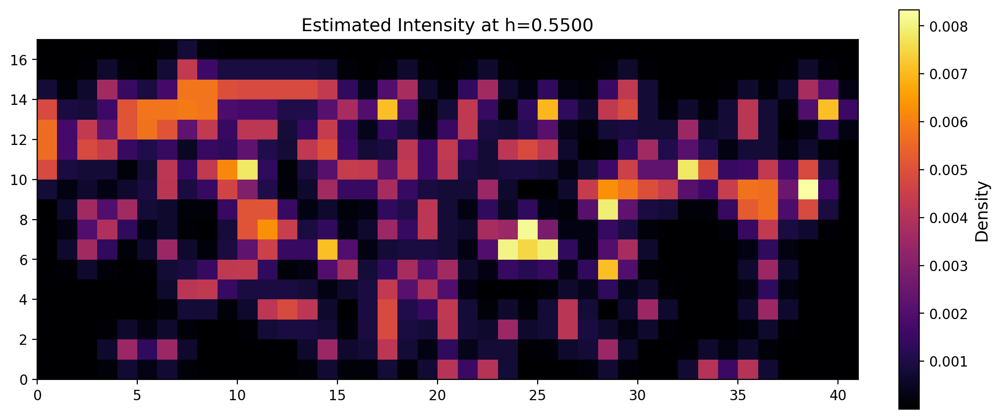

Estimating sigma via conditional likelihood on rectangle...
Local maxima (sigma, log-likelihood):
  Sigma: 0.1000, Log-Likelihood: -400.7246
  Sigma: 1.5500, Log-Likelihood: -391.2056


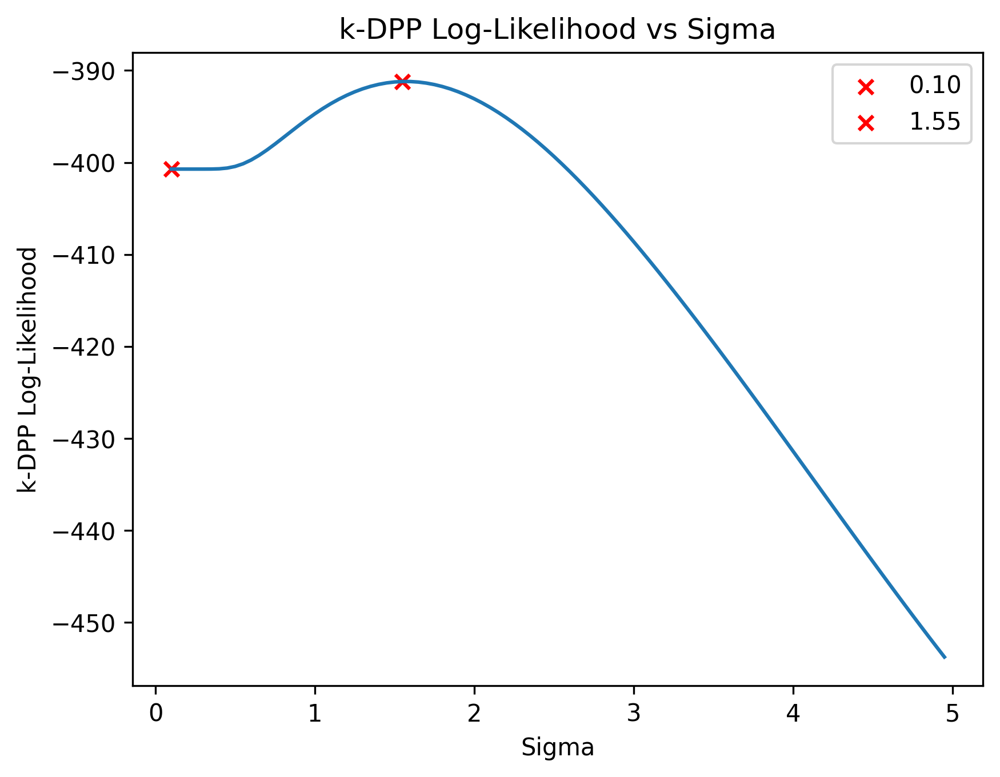

Evaluating candidate bandwidths...

--- Fold Results ---
Pilot bandwidth h     = 0.5500
Sigma                 = 1.5500
Candidate bandwidths h: 0.4950, 0.5500, 0.6050, 0.6600, 0.7150, 0.7700, 0.8250, 0.8800, 0.9350, 0.9900, 1.0450, 1.1000, 1.1550, 1.2100, 1.2650, 1.3200, 1.3750, 1.4300, 1.4850, 1.5400, 1.5950, 1.6500, 1.7050, 1.7600, 1.8150, 1.8700, 1.9250, 1.9800, 2.0350, 2.0900, 2.1450, 2.2000, 2.2550, 2.3100, 2.3650, 2.4200, 2.4750, 2.5300, 2.5850, 2.6400, 2.6950, 2.7500, 2.8050, 2.8600, 2.9150, 2.9700, 3.0250, 3.0800, 3.1350, 3.1900, 3.2450, 3.3000, 3.3550, 3.4100, 3.4650, 3.5200, 3.5750, 3.6300, 3.6850, 3.7400, 3.7950, 3.8500, 3.9050, 3.9600, 4.0150, 4.0700, 4.1250, 4.1800, 4.2350, 4.2900, 4.3450, 4.4000, 4.4550, 4.5100, 4.5650, 4.6200, 4.6750, 4.7300, 4.7850, 4.8400, 4.8950, 4.9500, 5.0050, 5.0600, 5.1150, 5.1700, 5.2250, 5.2800, 5.3350, 5.3900, 5.4450, 5.5000
Log-likelihoods on test set: -670.1714, -640.2637, -619.0069, -604.1202, -593.7602, -586.4878, -581.3565, -577.7680, -575.

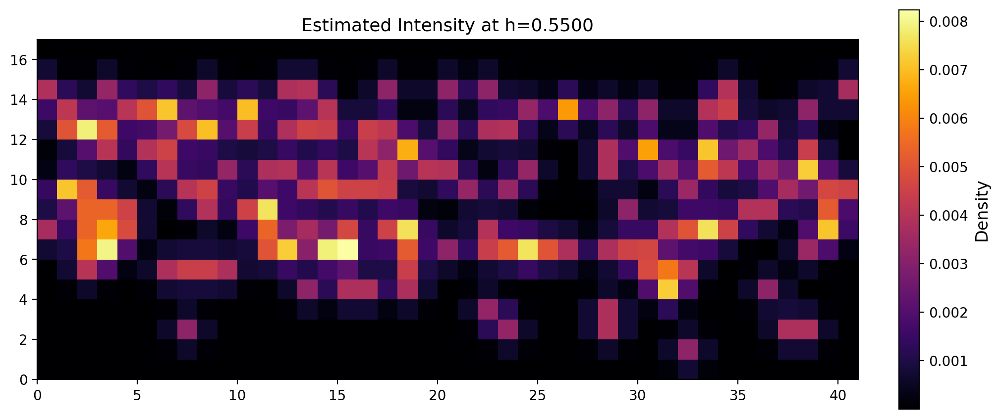

Estimating sigma via conditional likelihood on rectangle...
Local maxima (sigma, log-likelihood):
  Sigma: 0.1000, Log-Likelihood: -393.1439
  Sigma: 1.2000, Log-Likelihood: -388.2884


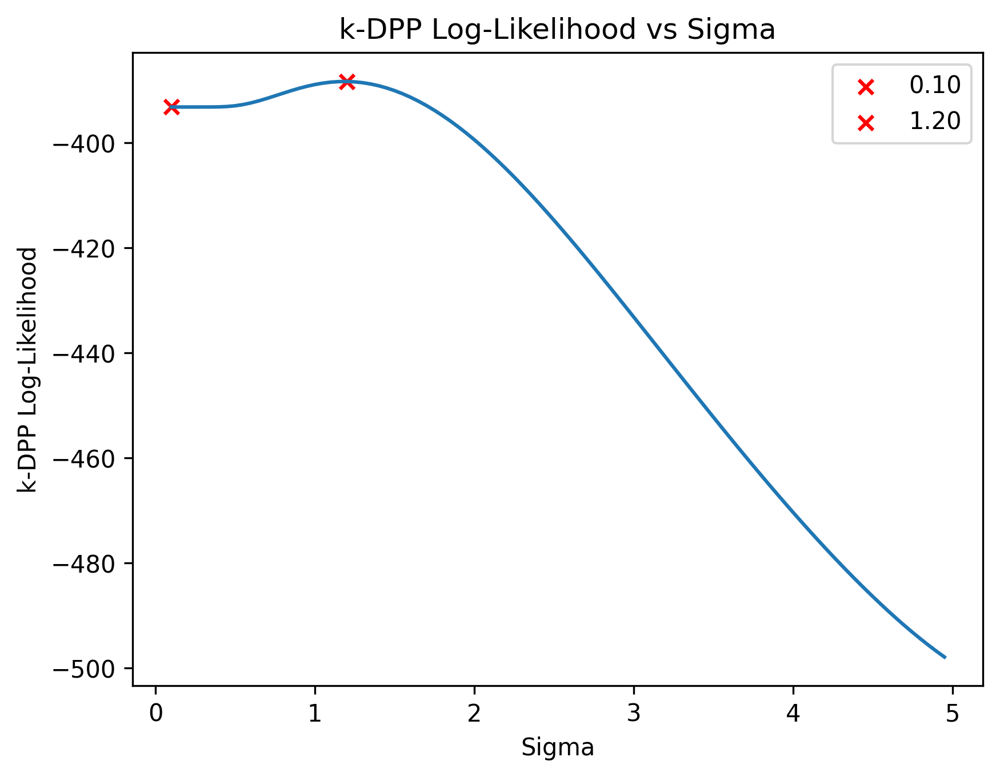

Evaluating candidate bandwidths...

--- Fold Results ---
Pilot bandwidth h     = 0.5500
Sigma                 = 1.2000
Candidate bandwidths h: 0.4950, 0.5500, 0.6050, 0.6600, 0.7150, 0.7700, 0.8250, 0.8800, 0.9350, 0.9900, 1.0450, 1.1000, 1.1550, 1.2100, 1.2650, 1.3200, 1.3750, 1.4300, 1.4850, 1.5400, 1.5950, 1.6500, 1.7050, 1.7600, 1.8150, 1.8700, 1.9250, 1.9800, 2.0350, 2.0900, 2.1450, 2.2000, 2.2550, 2.3100, 2.3650, 2.4200, 2.4750, 2.5300, 2.5850, 2.6400, 2.6950, 2.7500, 2.8050, 2.8600, 2.9150, 2.9700, 3.0250, 3.0800, 3.1350, 3.1900, 3.2450, 3.3000, 3.3550, 3.4100, 3.4650, 3.5200, 3.5750, 3.6300, 3.6850, 3.7400, 3.7950, 3.8500, 3.9050, 3.9600, 4.0150, 4.0700, 4.1250, 4.1800, 4.2350, 4.2900, 4.3450, 4.4000, 4.4550, 4.5100, 4.5650, 4.6200, 4.6750, 4.7300, 4.7850, 4.8400, 4.8950, 4.9500, 5.0050, 5.0600, 5.1150, 5.1700, 5.2250, 5.2800, 5.3350, 5.3900, 5.4450, 5.5000
Log-likelihoods on test set: -663.4640, -637.8995, -620.2725, -607.9936, -599.0355, -591.9665, -586.0779, -581.1359, -577.

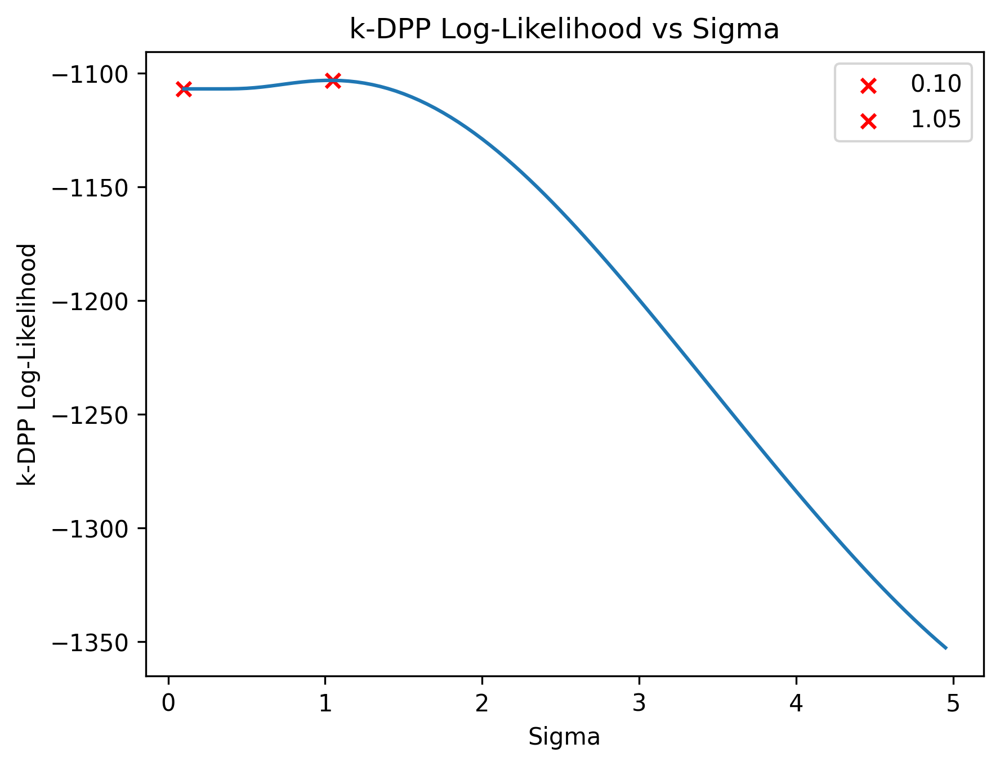

Selected bandwidth h: 1.3200
Selected sigma: 1.0500


In [ ]:
# Inference with for DPP model
from dpp.inference_dpp import iterative_refinement as iterative_refinement_dpp

# for the demo, we will just run two iterations and two folds of cross-validation
results_dpp = iterative_refinement_dpp(
    rectangle_data,
    samples_rect,
    rectangle_grid,
    rectangle_grid,
    conditioned=True,
    n_iter=2,
    k_folds=2
)

# expect a runtime of ~20min

## GPP Inference

For GPPs, which are continuous models, we do not need to use the discretized data. As for DPPs, we restrict ourselves to the same rectangular estimation area. In addition, we again use a small subsample of the data for this demonstration, as well as fewer folds and iterations, in the interest of time. 

# Strauss

We begin with a Strauss interaction function, i.e. a model with pdf given by
$$ f(\mathbf{x}) \propto \beta(\mathbf{x}) \vartheta^{s(\mathbf{x})}, \quad \text{where } s(\mathbf{x}) = \sum_{\substack{x, y \in \mathbf{x} \\ x \neq y}} \mathbf{1}\{\|x - y\| < R\}, $$
where $\mathbf{1}$ denotes an indicator function, $R > 0$ is the interaction radius, $\vartheta \in (0, 1]$ the repulsion strength, and $\mathbf{x}$ denotes a configuration of points.


========== Iteration 1/2 ==========

========== Fold 1/2 ==========
Estimating pilot bandwidth via Poisson-likelihood CV…


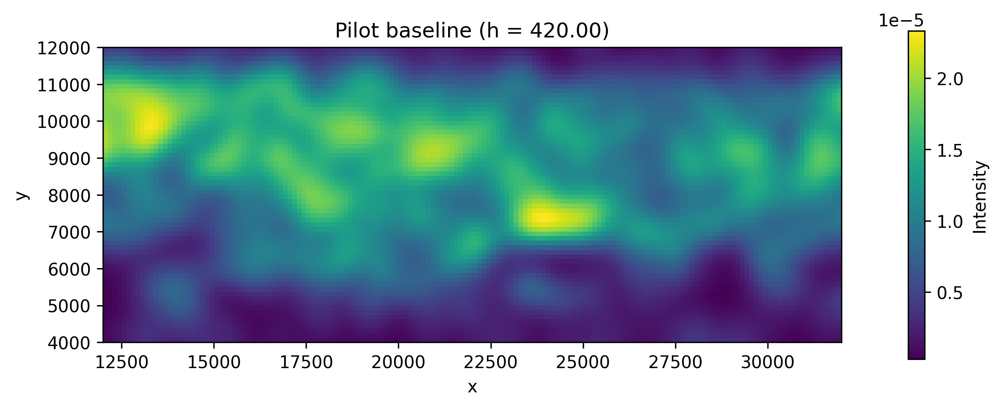

Estimating interaction parameters (conditional MPLE)…
Evaluating bandwidths on the test split (conditional CPL)…

--- Fold Results ---
Pilot bandwidth h     = 420.0000
R                 = 350.0000
Alpha             = -2.9957
Gamma             = 0.0500
Candidate bandwidths h: 210.0000, 231.0000, 252.0000, 273.0000, 294.0000, 315.0000, 336.0000, 357.0000, 378.0000, 399.0000, 420.0000, 441.0000, 462.0000, 483.0000, 504.0000, 525.0000, 546.0000, 567.0000, 588.0000, 609.0000, 630.0000
Log-likelihoods on test set: -22757.5654, -22729.4027, -22709.5408, -22695.3603, -22685.1783, -22677.8768, -22672.6916, -22669.0879, -22666.6832, -22665.1989, -22664.4285, -22664.2162, -22664.4424, -22665.0140, -22665.8576, -22666.9144, -22668.1374, -22669.4887, -22670.9380, -22672.4611, -22674.0387

========== Fold 2/2 ==========
Estimating pilot bandwidth via Poisson-likelihood CV…


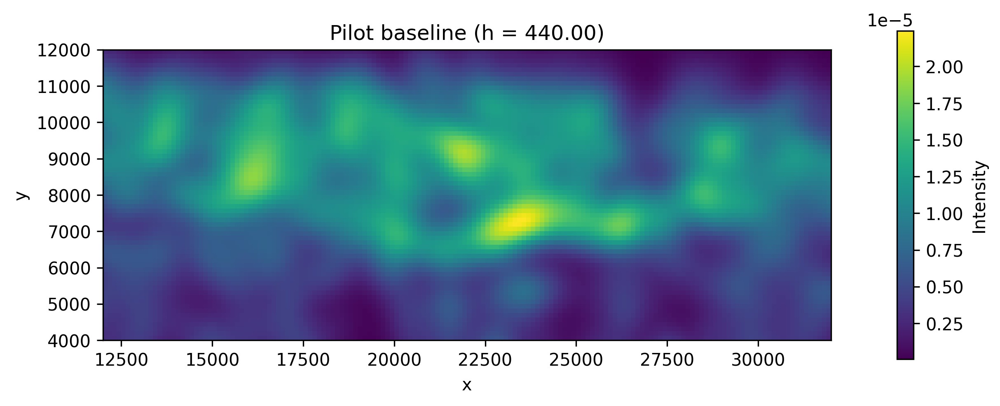

Estimating interaction parameters (conditional MPLE)…
Evaluating bandwidths on the test split (conditional CPL)…

--- Fold Results ---
Pilot bandwidth h     = 440.0000
R                 = 400.0000
Alpha             = -1.8971
Gamma             = 0.1500
Candidate bandwidths h: 220.0000, 242.0000, 264.0000, 286.0000, 308.0000, 330.0000, 352.0000, 374.0000, 396.0000, 418.0000, 440.0000, 462.0000, 484.0000, 506.0000, 528.0000, 550.0000, 572.0000, 594.0000, 616.0000, 638.0000, 660.0000
Log-likelihoods on test set: -26670.6847, -26637.9500, -26615.1602, -26598.9964, -26587.3802, -26578.9763, -26572.9052, -26568.5726, -26565.5658, -26563.5899, -26562.4277, -26561.9143, -26561.9213, -26562.3466, -26563.1084, -26564.1404, -26565.3893, -26566.8121, -26568.3745, -26570.0494, -26571.8153

=========== Cross‑validated Summary ===========
R0 : mean=375.0000, sd=25.0000
alpha0 : mean=-2.4464, sd=0.5493
h0 : mean=430.0000, sd=10.0000
gamma0 : mean=0.1000, sd=0.0500

Candidate bandwidths h (averaged over

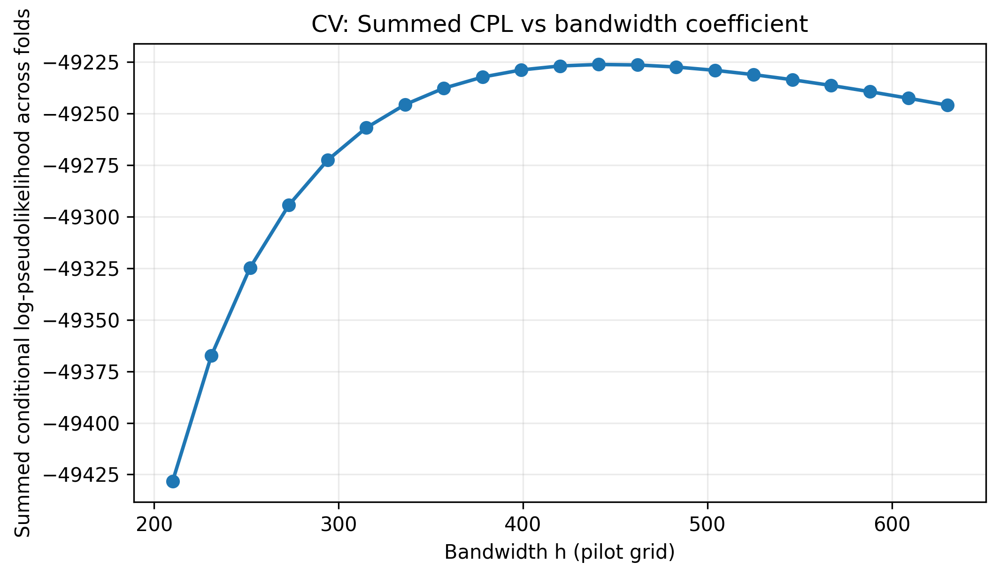

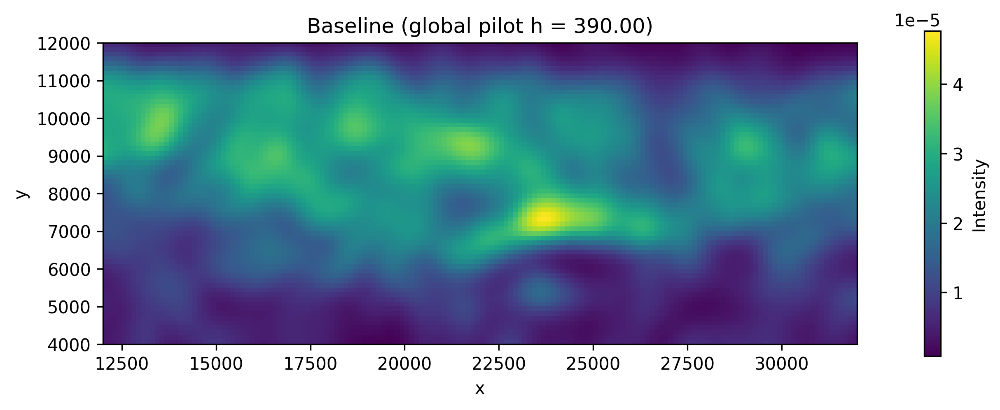

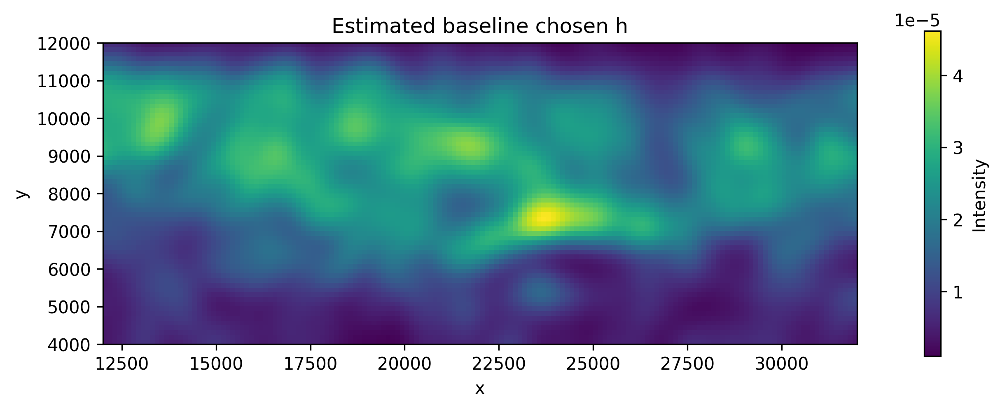

Estimating interaction parameters at pilot bandwidth…
At pilot bandwidth: R = 400.0000, alpha = -1.8971
Re‑estimating interaction parameters at the selected bandwidth…
At selected bandwidth: R = 400.0000, alpha = -1.8971, gamma = 0.1500


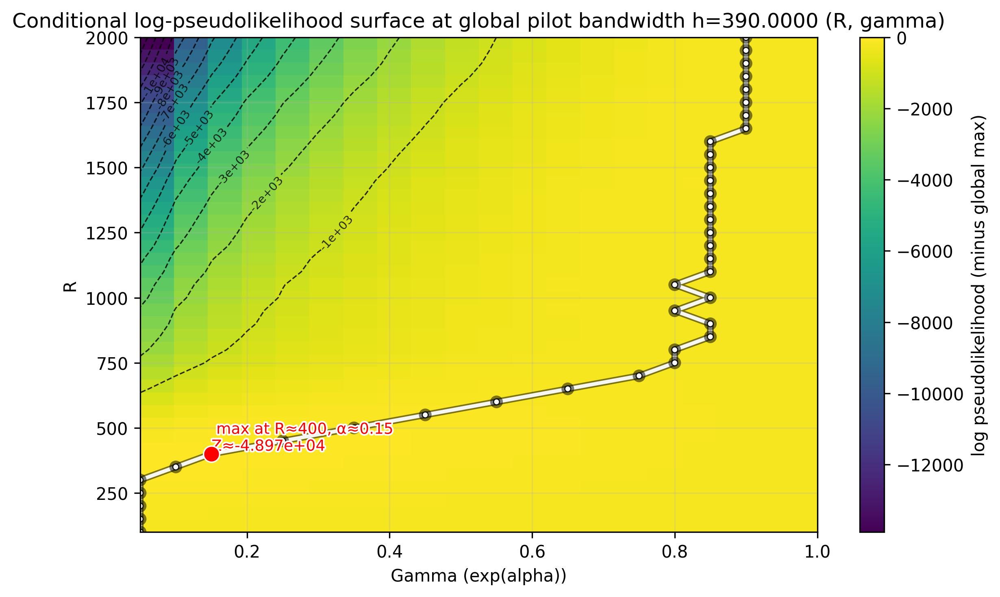

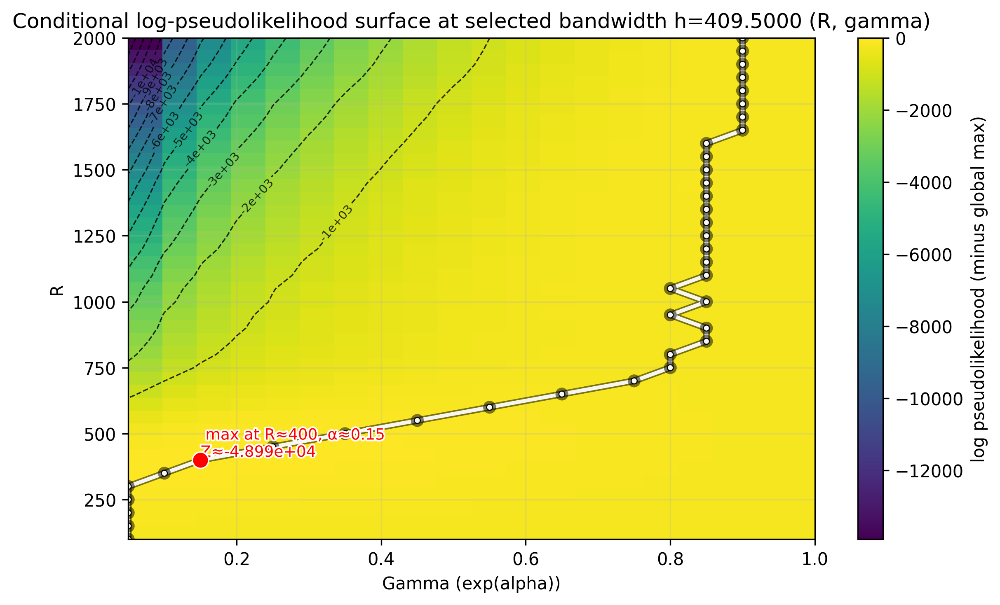

Selected bandwidth h = 409.5000, R = 400.0000, alpha = -1.8971

========== Iteration 2/2 ==========

========== Fold 1/2 ==========
Estimating interaction parameters (conditional MPLE)…
Evaluating bandwidths on the test split (conditional CPL)…

--- Fold Results ---
Pilot bandwidth h     = 409.5000
R                 = 350.0000
Alpha             = -2.9957
Gamma             = 0.0500
Candidate bandwidths h: 204.7500, 225.2250, 245.7000, 266.1750, 286.6500, 307.1250, 327.6000, 348.0750, 368.5500, 389.0250, 409.5000, 429.9750, 450.4500, 470.9250, 491.4000, 511.8750, 532.3500, 552.8250, 573.3000, 593.7750, 614.2500
Log-likelihoods on test set: -22766.3492, -22736.1778, -22714.8062, -22699.4629, -22688.3662, -22680.3318, -22674.5500, -22670.4536, -22667.6367, -22665.8036, -22664.7352, -22664.2661, -22664.2698, -22664.6478, -22665.3224, -22666.2317, -22667.3256, -22668.5641, -22669.9144, -22671.3504, -22672.8510

========== Fold 2/2 ==========
Estimating interaction parameters (conditional MPL

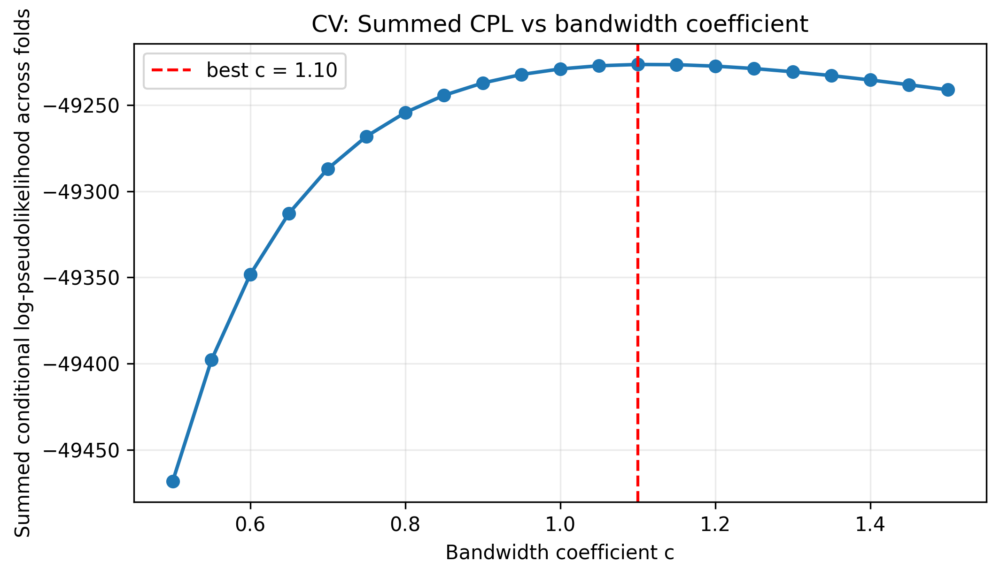

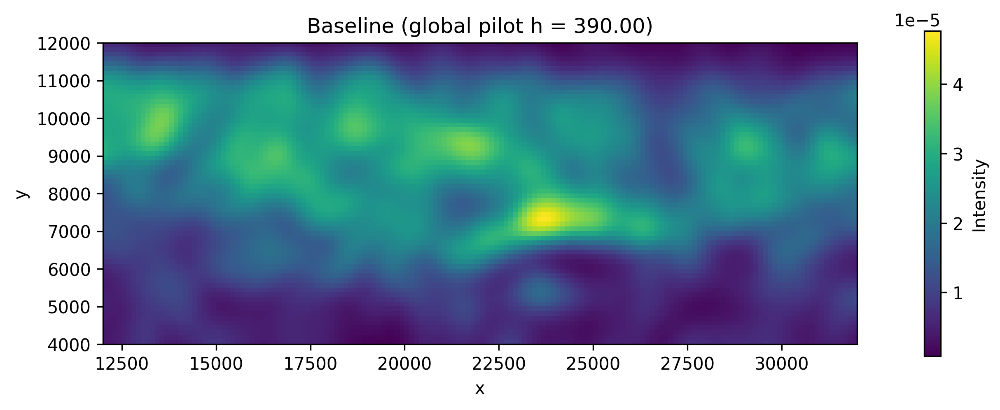

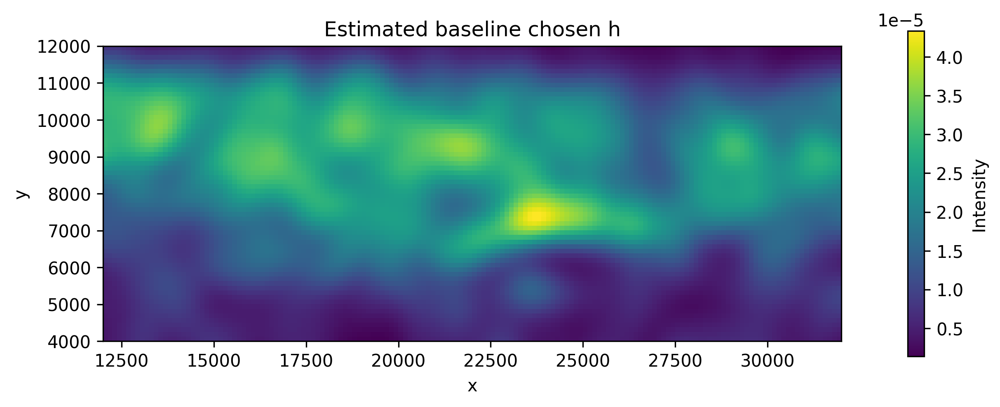

Estimating interaction parameters at pilot bandwidth…
At pilot bandwidth: R = 400.0000, alpha = -1.8971
Re‑estimating interaction parameters at the selected bandwidth…
At selected bandwidth: R = 400.0000, alpha = -1.8971, gamma = 0.1500


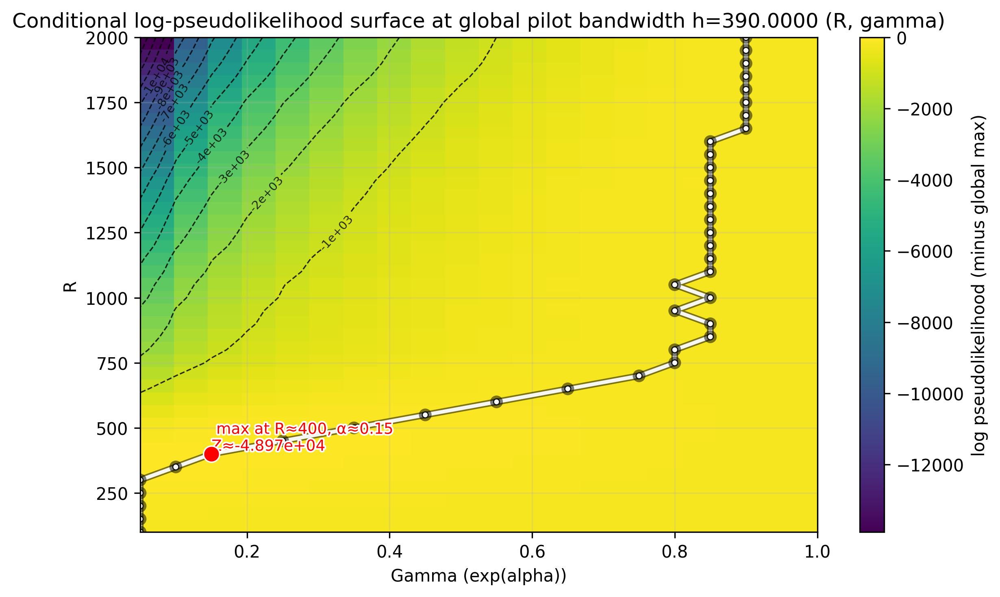

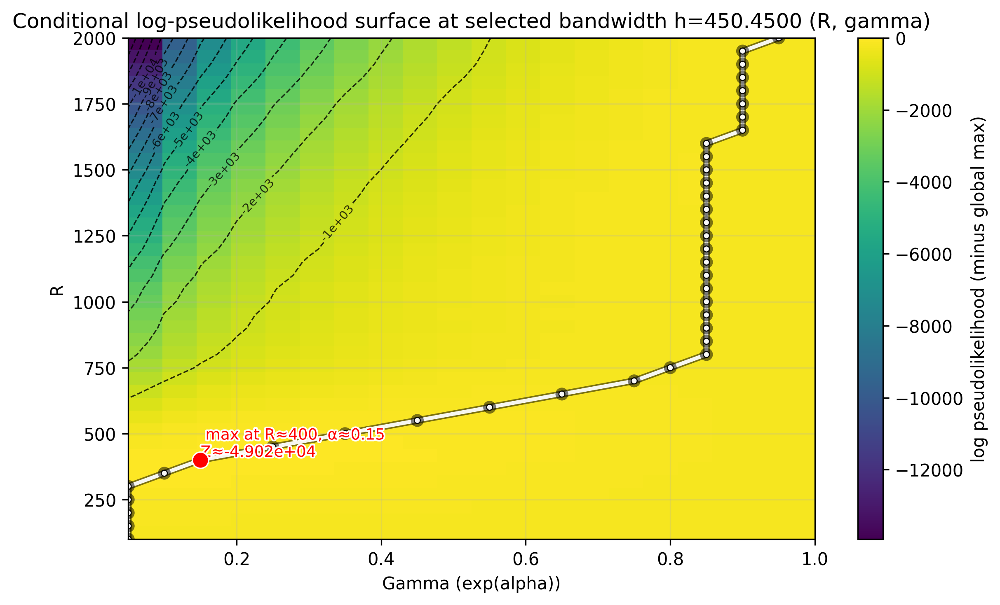

Selected bandwidth h = 450.4500, R = 400.0000, alpha = -1.8971


In [7]:
from gpp.inference_strauss import iterative_refinement as iterative_refinement_strauss
from gpp.inference_gpp_backend import df_to_configs

xmin, ymin, xmax, ymax = 12000, 4000, 32000, 12000 # rectangle
window = (xmin, ymin, xmax, ymax)

# as before, we want samples as arrays of points
# However, we don't want grid indices like before. 
# df_to_configs produces an array of arrays of points, one for each snapshot
data = pd.read_parquet("data/snapshots.parquet")
rectangle_data = data[
    (data.x_position_mm >= window[0]) & 
    (data.x_position_mm <= window[2]) & 
    (data.y_position_mm >= window[1]) & 
    (data.y_position_mm <= window[3])
]

configs, _, _ = df_to_configs(rectangle_data)
configs = np.array(configs, dtype=object)

results_strauss = iterative_refinement_strauss(
    configs,
    n_iter=2,
    k_folds=2,
    window=window,
    grid=(160, 64), # grid for bandwidth selection
)

# expect a runtime of ~30min

## DGS 

Next, we will demonstrate the estimation of the Gibbs point process with modified Diggle-Gates-Stibbard interaction function, given by
$$ \gamma(x, y) = 
    \begin{cases}
    \Biggl( \sin \Bigl( \dfrac{\pi \, \|x - y\|}{2 R} \Bigr) \Biggr)^{2\alpha}, & \text{if } \|x - y\| < R, \\[2mm]
    1, & \text{if } \|x - y\| \ge R.
    \end{cases} $$
Here, $R$ again denotes the interaction radius, and $\alpha$ is a shape parameter determining how abrupt the transition is between full exclusion and independence. Confer Fig. 8 in the pre-print.


========== Iteration 1/2 ==========

========== Fold 1/2 ==========
Estimating pilot bandwidth via Poisson-likelihood CV…


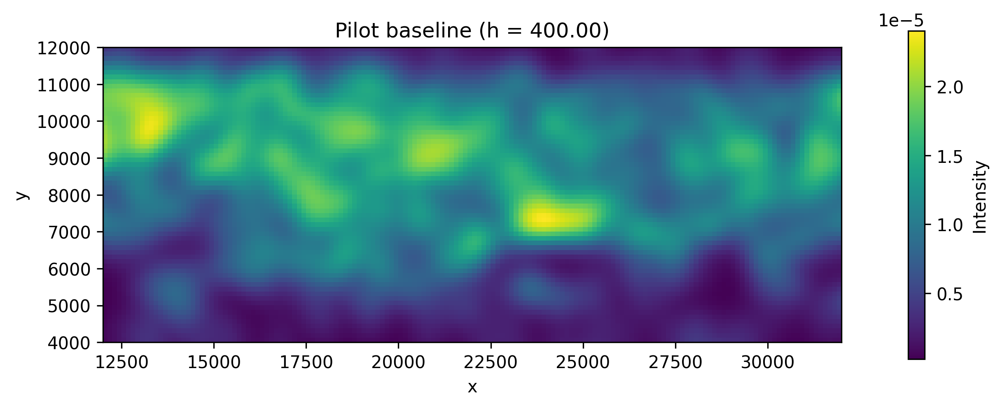

Estimating interaction parameters (conditional MPLE)…
Evaluating bandwidths on the test split (conditional CPL)…

--- Fold Results ---
Pilot bandwidth h     = 400.0000
R                 = 550.0000
Alpha             = 4.2000
Candidate bandwidths h: 200.0000, 220.0000, 240.0000, 260.0000, 280.0000, 300.0000, 320.0000, 340.0000, 360.0000, 380.0000, 400.0000, 420.0000, 440.0000, 460.0000, 480.0000, 500.0000, 520.0000, 540.0000, 560.0000, 580.0000
Log-likelihoods on test set: -22744.7872, -22712.7518, -22690.0154, -22673.6572, -22661.7975, -22653.1862, -22646.9674, -22642.5410, -22639.4770, -22637.4616, -22636.2620, -22635.7028, -22635.6496, -22635.9981, -22636.6659, -22637.5876, -22638.7101, -22639.9908, -22641.3949, -22642.8941

========== Fold 2/2 ==========
Estimating pilot bandwidth via Poisson-likelihood CV…


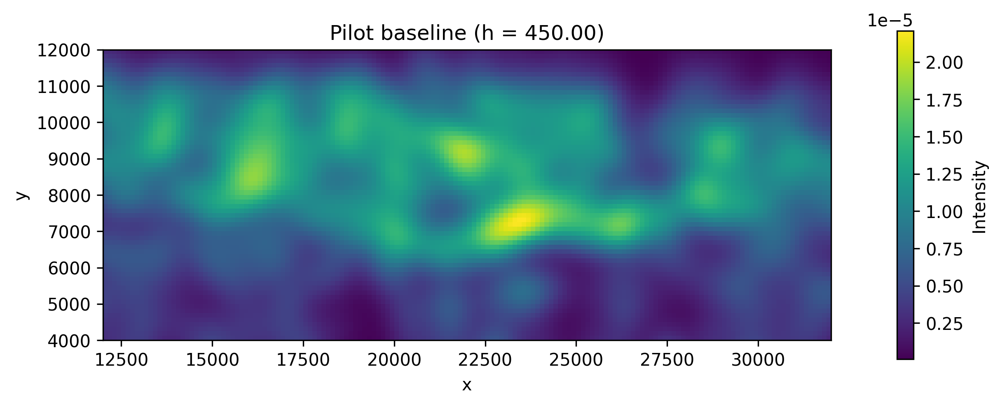

Estimating interaction parameters (conditional MPLE)…
Evaluating bandwidths on the test split (conditional CPL)…

--- Fold Results ---
Pilot bandwidth h     = 450.0000
R                 = 600.0000
Alpha             = 2.6000
Candidate bandwidths h: 225.0000, 247.5000, 270.0000, 292.5000, 315.0000, 337.5000, 360.0000, 382.5000, 405.0000, 427.5000, 450.0000, 472.5000, 495.0000, 517.5000, 540.0000, 562.5000, 585.0000, 607.5000, 630.0000, 652.5000
Log-likelihoods on test set: -26642.5710, -26612.0122, -26590.8373, -26575.9077, -26565.2647, -26557.6531, -26552.2471, -26548.4882, -26545.9875, -26544.4660, -26543.7165, -26543.5809, -26543.9357, -26544.6823, -26545.7418, -26547.0509, -26548.5586, -26550.2246, -26552.0166, -26553.9097

=========== Cross‑validated Summary ===========
R0 : mean=575.0000, sd=25.0000
alpha0 : mean=3.4000, sd=0.8000
h0 : mean=425.0000, sd=25.0000

Candidate bandwidths h (averaged over folds): 212.5000, 233.7500, 255.0000, 276.2500, 297.5000, 318.7500, 340.0000, 361.2

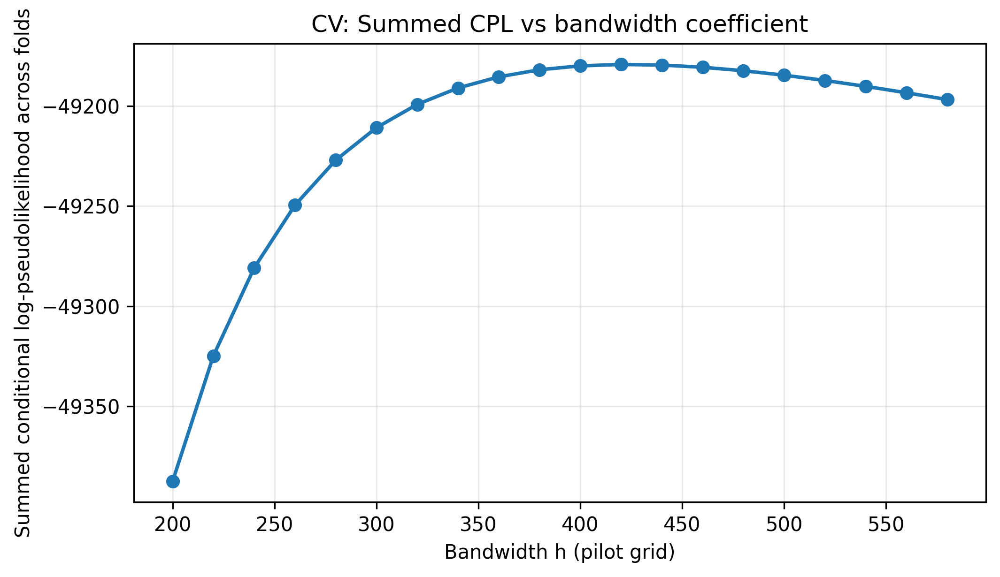

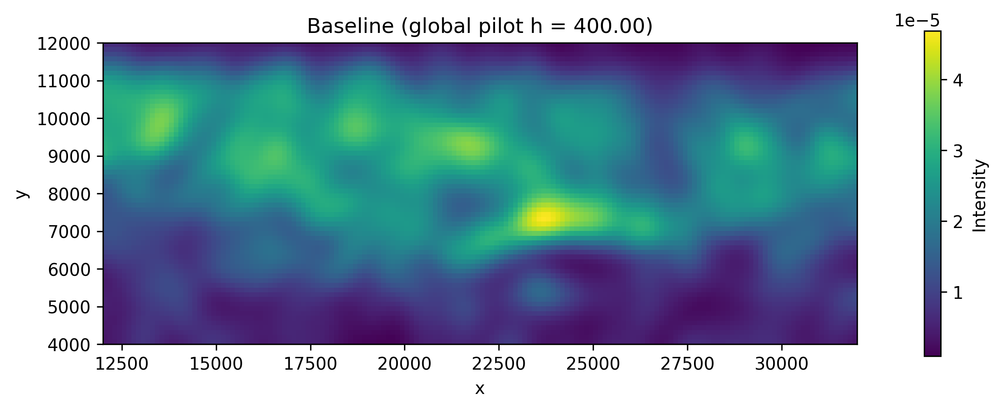

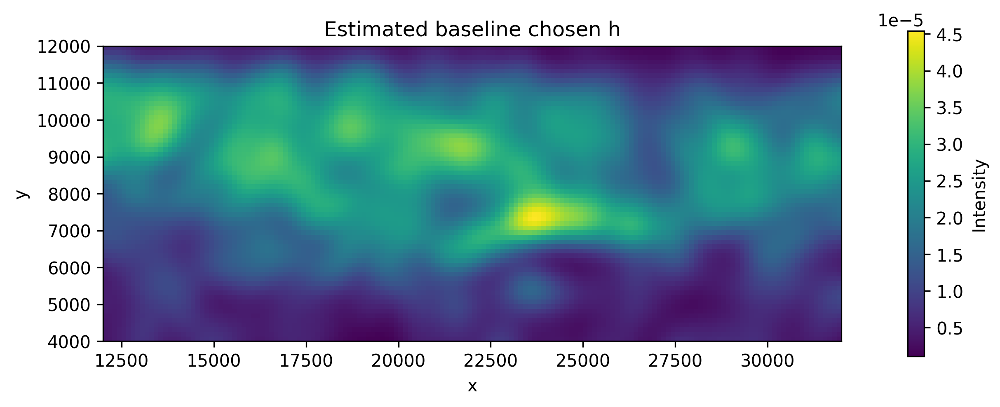

Estimating interaction parameters at pilot bandwidth…
At pilot bandwidth: R = 550.0000, alpha = 3.7000
Re‑estimating interaction parameters at the selected bandwidth…
At selected bandwidth: R = 550.0000, alpha = 3.7000


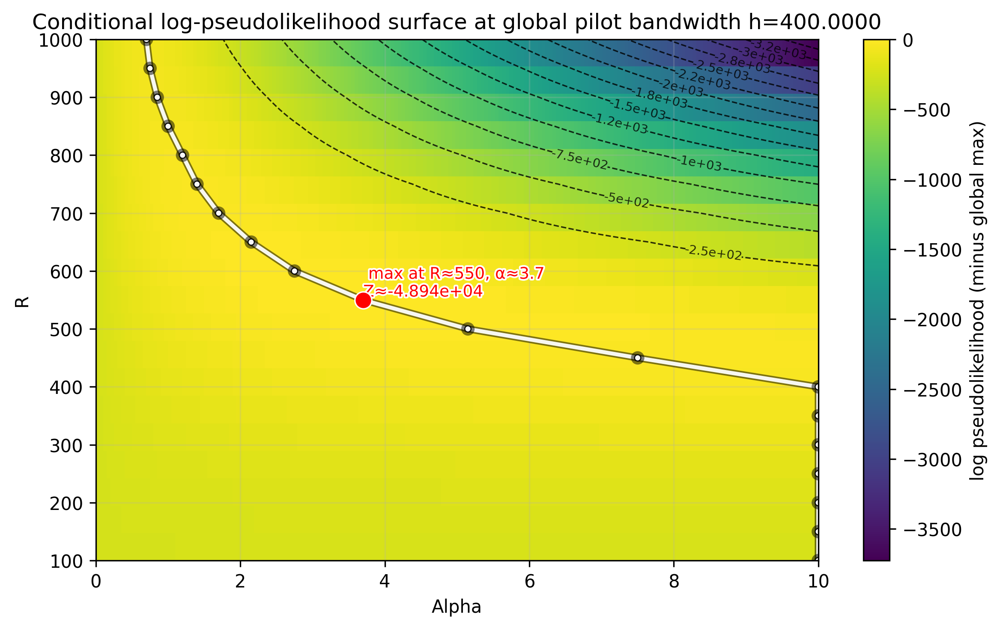

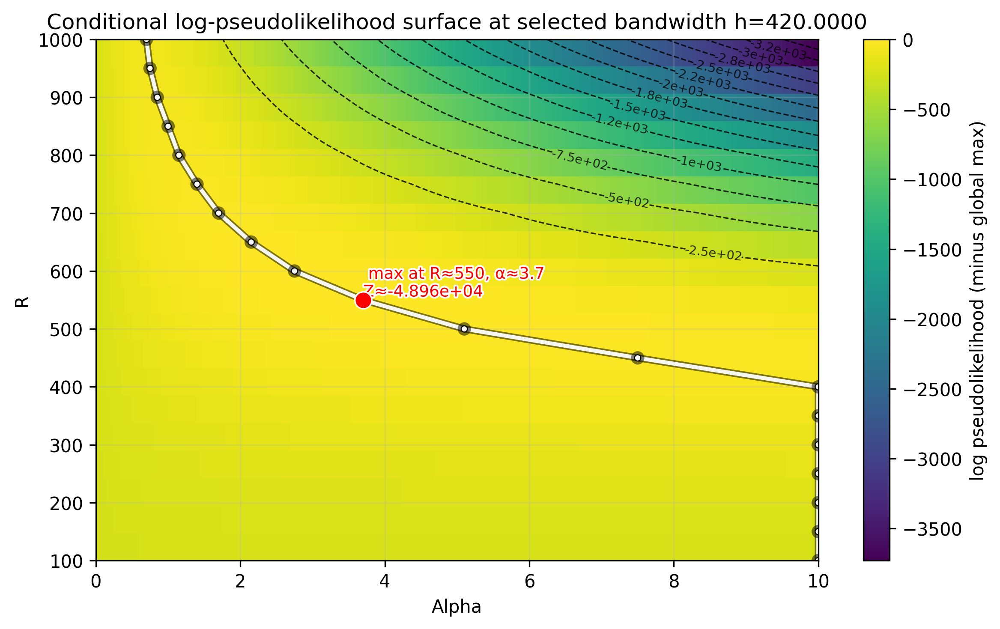

Selected bandwidth h = 420.0000, R = 550.0000, alpha = 3.7000

========== Iteration 2/2 ==========

========== Fold 1/2 ==========
Estimating interaction parameters (conditional MPLE)…
Evaluating bandwidths on the test split (conditional CPL)…

--- Fold Results ---
Pilot bandwidth h     = 420.0000
R                 = 550.0000
Alpha             = 4.2000
Candidate bandwidths h: 210.0000, 231.0000, 252.0000, 273.0000, 294.0000, 315.0000, 336.0000, 357.0000, 378.0000, 399.0000, 420.0000, 441.0000, 462.0000, 483.0000, 504.0000, 525.0000, 546.0000, 567.0000, 588.0000, 609.0000
Log-likelihoods on test set: -22727.3668, -22699.3133, -22679.5728, -22665.5250, -22655.4853, -22648.3341, -22643.3055, -22639.8631, -22637.6231, -22636.3055, -22635.7028, -22635.6582, -22636.0517, -22636.7894, -22637.7975, -22639.0170, -22640.4005, -22641.9100, -22643.5152, -22645.1916

========== Fold 2/2 ==========
Estimating interaction parameters (conditional MPLE)…
Evaluating bandwidths on the test split (conditi

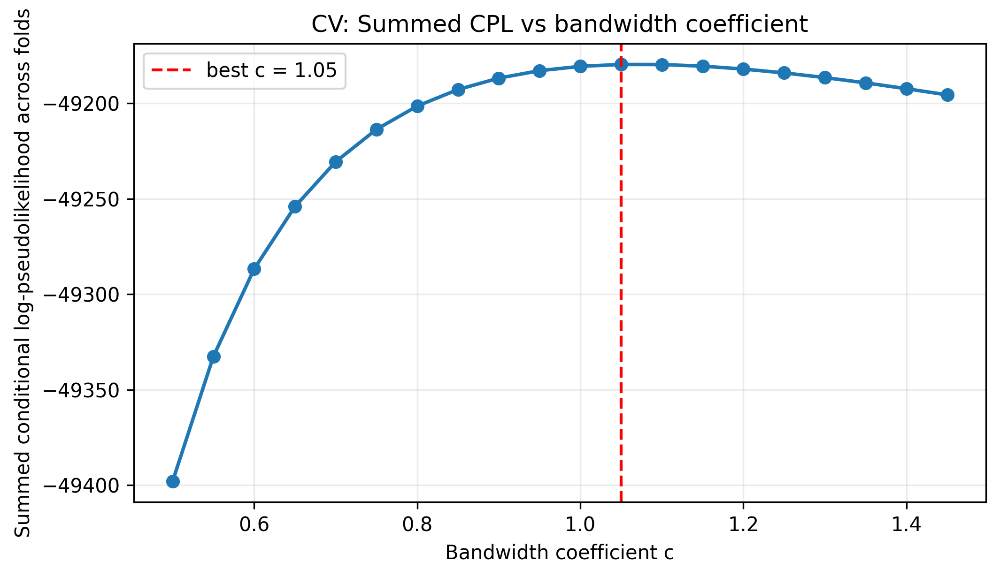

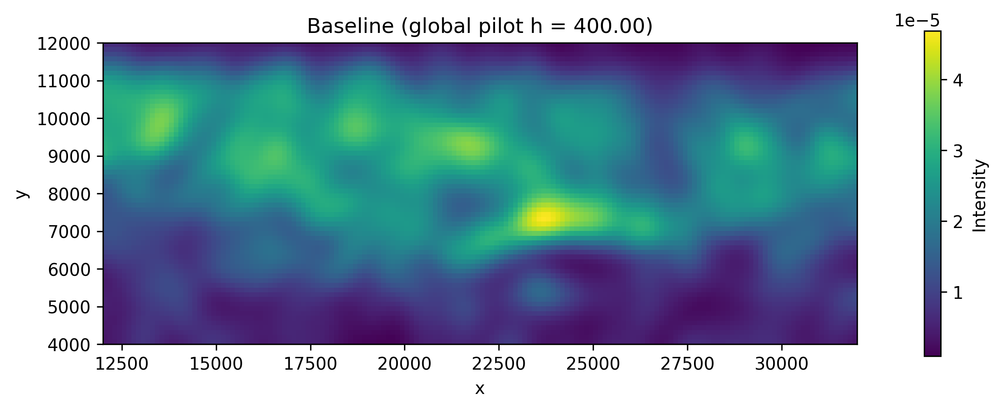

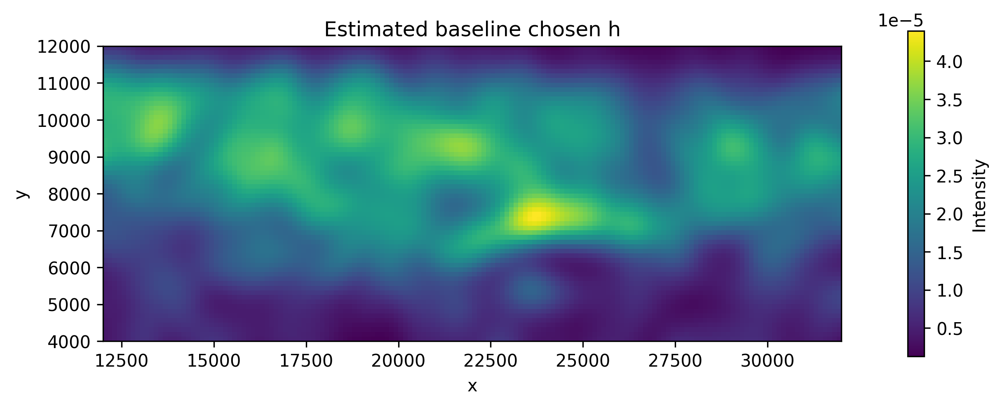

Estimating interaction parameters at pilot bandwidth…
At pilot bandwidth: R = 550.0000, alpha = 3.7000
Re‑estimating interaction parameters at the selected bandwidth…
At selected bandwidth: R = 550.0000, alpha = 3.6500


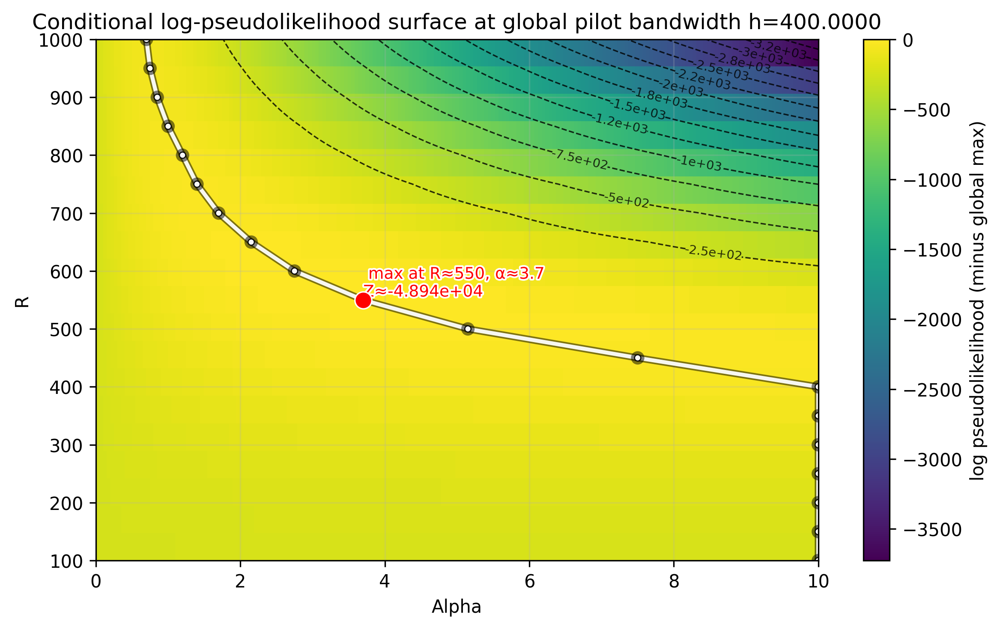

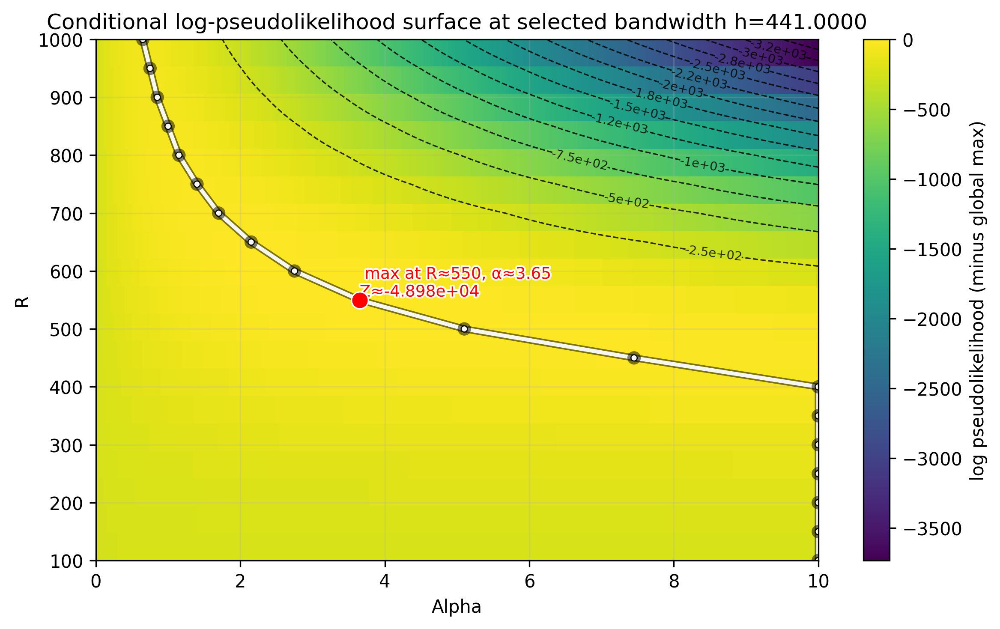

Selected bandwidth h = 441.0000, R = 550.0000, alpha = 3.6500


In [8]:
from gpp.inference_dgs import iterative_refinement as iterative_refinement_dgs
from gpp.inference_gpp_backend import df_to_configs

xmin, ymin, xmax, ymax = 12000, 4000, 32000, 12000 # rectangle
window = (xmin, ymin, xmax, ymax)

# as before, we want samples as arrays of points
# However, we don't want grid indices like before. 
# df_to_configs produces an array of arrays of points, one for each snapshot
data = pd.read_parquet("data/snapshots.parquet")
rectangle_data = data[
    (data.x_position_mm >= window[0]) & 
    (data.x_position_mm <= window[2]) & 
    (data.y_position_mm >= window[1]) & 
    (data.y_position_mm <= window[3])
]

configs, _, _ = df_to_configs(rectangle_data)
configs = np.array(configs, dtype=object)

results_dgs = iterative_refinement_dgs(
    configs,
    n_iter=2,
    k_folds=2,
    window=window,
    grid=(160, 64), # grid for bandwidth selection
)

# expect a runtime of ~45min